In [ ]:
# operator_density_pipeline.py

import math
import itertools
from dataclasses import dataclass
from typing import Optional, Tuple, Dict, Any

import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.hermite_e import hermeval

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import Dataset, DataLoader
except Exception:
    torch = None
    nn = None
    Dataset = object
    DataLoader = None



In [9]:
!pip install xsuite


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 759.1/759.1 kB 20.7 MB/s eta 0:00:0000:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.2/240.2 kB 23.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.8/77.8 kB 9.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.6/51.6 kB 5.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 20.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4

/usr/local/lib/python3.12/dist-packages/cupyx/jit/_interface.py:247: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


xtrack version 0.101.4
Saved to xsuite_operator_dataset.npz: (200, 4000, 6) (200, 4000, 6) (200, 3)
Dataset shapes: X = (50000, 6) , Y = (50000, 6)
Dataset saved to xsuite_dataset.npz


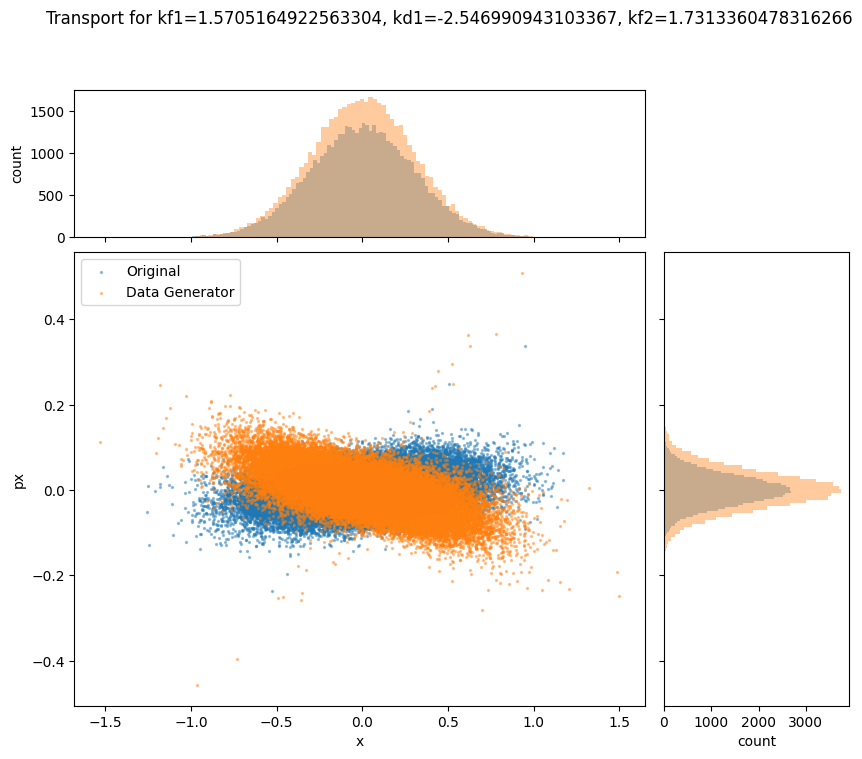

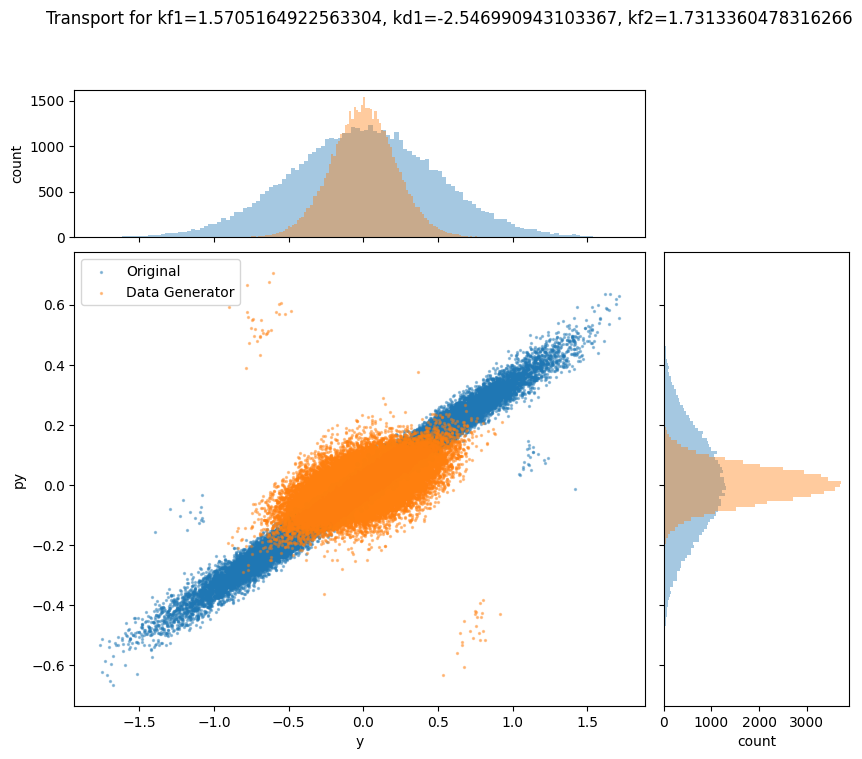

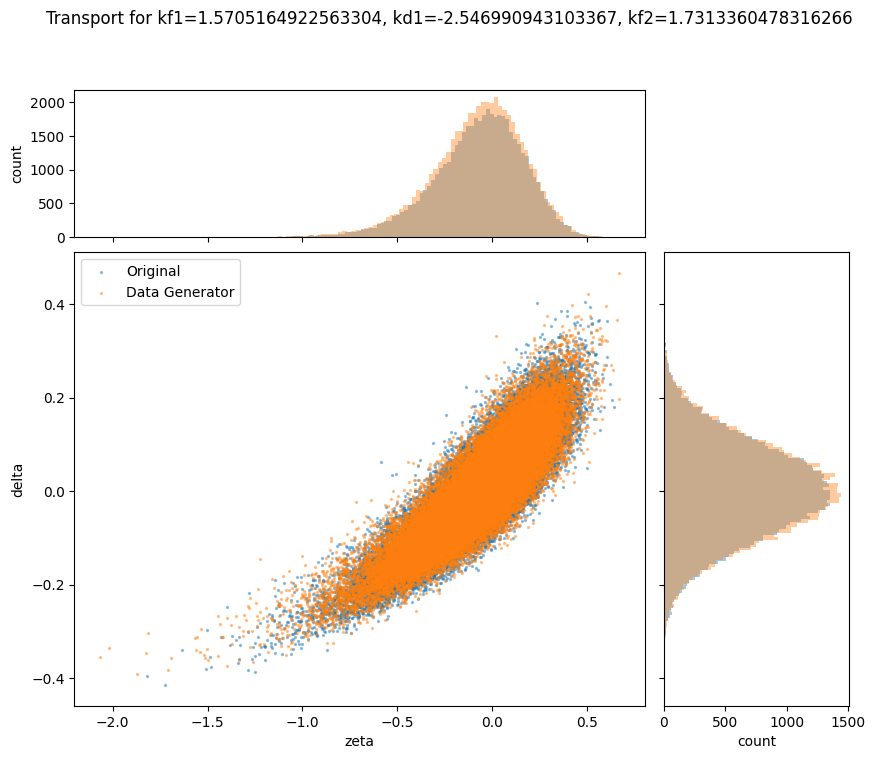

In [10]:
#import useful libraries
import numpy as np  # arrays and math
import matplotlib.pyplot as plt  # plots
import xtrack as xt  # tracking module of Xsuite
#%matplotlib widget

def plot_phase_space_with_profiles(x_array, px_array, title="",axis_labels = None, label=None, bins=120, difference=False)->None:
    fig = plt.figure(figsize=(10, 8))
    gs = fig.add_gridspec(
        2, 2,
        width_ratios=(4, 1.3),
        height_ratios=(1.3, 4),
        hspace=0.05,
        wspace=0.05
    )

    ax_histx = fig.add_subplot(gs[0, 0])
    ax_scatter = fig.add_subplot(gs[1, 0])
    ax_histpx = fig.add_subplot(gs[1, 1])

    # Scatter
    number_of_plots = len(x_array) if isinstance(x_array, list) else 1
    if number_of_plots > 1:
        for i in range(number_of_plots):
            x = x_array[i]
            px = px_array[i]
            lbl = label[i] if label is not None else None
            ax_scatter.scatter(x, px, s=2, alpha=0.4, label=lbl)
    else:
        x = x_array if not isinstance(x_array, list) else x_array[0]
        px = px_array if not isinstance(px_array, list) else px_array[0]

    ax_scatter.set_xlabel("x") if axis_labels is None else ax_scatter.set_xlabel(axis_labels[0])
    ax_scatter.set_ylabel("px") if axis_labels is None else ax_scatter.set_ylabel(axis_labels[1])
    if label is not None:
        ax_scatter.legend()

    # x profile
    if number_of_plots > 1:
        for i in range(number_of_plots):
            x = x_array[i]
            lbl = label[i] if label is not None else None
            ax_histx.hist(x, bins=bins, alpha=0.4, label=lbl)
            if difference and i == 1:  # If difference is True, plot the difference for the second dataset
                x_diff = x - (x_array[0] if not isinstance(x_array[0], list) else x_array[0][i])
                ax_histx.hist(x_diff, bins=bins, alpha=0.4, label=f"{lbl} Difference")

    else:
        x = x_array if not isinstance(x_array, list) else x_array[0]
        ax_histx.hist(x, bins=bins, alpha=0.4)

    ax_histx.set_ylabel("count")
    ax_histx.tick_params(axis="x", labelbottom=False)

    # px profile
    if number_of_plots > 1:
        for i in range(number_of_plots):
            px = px_array[i]
            lbl = label[i] if label is not None else None
            ax_histpx.hist(px, bins=bins, orientation="horizontal", alpha=0.4, label=lbl)
            if difference and i == 1:  # If difference is True, plot the difference for the second dataset
                px_diff = px - (px_array[0] if not isinstance(px_array[0], list) else px_array[0][i])
                ax_histpx.hist(px_diff, bins=bins, orientation="horizontal", alpha=0.4, label=f"{lbl} Difference")
    else:
        px = px_array if not isinstance(px_array, list) else px_array[0]
        ax_histpx.hist(px, bins=bins, orientation="horizontal", alpha=0.4)

    ax_histpx.set_xlabel("count")
    ax_histpx.tick_params(axis="y", labelleft=False)

    fig.suptitle(title)
    plt.show()


##################################

print('xtrack version', xt.__version__)

# Reference energy


part = xt.Particles(mass0=xt.PROTON_MASS_EV, p0c=1e9)  # Mass eV/c^2 Momentum in eV/c

# Element geometry
env=xt.Environment()
env.vars.default_to_zero = True
env['l_mq'] = 0.4


env.new('mq', xt.Quadrupole, length='l_mq')
env.new('qf1', 'mq', k1='kf1') # Focusing quadrupole  k1>0
env.new('qf2', 'mq', k1='kf2') # Focusing quadrupole  k1>0
env.new('qd1', 'mq', k1='kd1') # De-focusing quadrupole k1<0
#Markers
env.new("start_cell",xt.Marker)
env.new("end_cell",xt.Marker)


line = env.new_line(
    length=4, # 4 m length
    components=[
    env.place('start_cell', at=0),
    env.place('qf1', at=1),
    env.place('qd1', at=2),   # refer to the center by default
    env.place('qf2', at=3),
    env.place('end_cell',at=4),
    ]
)
line.particle_ref=part
line.build_tracker()


kf1 = 1.0; kd1 = -1.0 ; kf2 = 1.0

env['kf1'] = kf1
env['kd1'] = kd1
env['kf2'] = kf2

rng = np.random.default_rng(200)
n_particles = 50000

p0 = line.build_particles(
    x     = rng.normal(0.0, 1e-1, n_particles),
    y     = rng.normal(0.0, 1e-1, n_particles),
    zeta  = rng.normal(0.0, 1e-1, n_particles),
    px    = rng.normal(0.0, 1e-1, n_particles),
    py    = rng.normal(0.0, 1e-1, n_particles),
    delta = rng.normal(0.0, 1e-1, n_particles)
)
line.track(p0, turn_by_turn_monitor="ONE_TURN_EBE")





def sample_initial_conditions(n_particles: int, rng: np.random.Generator, dimensions : list) -> np.ndarray:

    [x,y,zeta,px,py,delta] = [rng.normal(0.0, dimensions[i], n_particles) for i in range(len(dimensions))]


    ## it must be separated as {[x0,y0,zeta0,px0,py0,delta0], [x1,y1,zeta1,px1,py1,delta1], ...} -> column stack

    return np.column_stack([x, y, zeta, px, py, delta]).astype(np.float64)

def particles_to_6d(particles: xt.Particles) -> np.ndarray:
    # Henon order: [q, p] = [x, y, zeta, px, py, delta]
    return np.column_stack([
        np.array(particles.x),
        np.array(particles.y),
        np.array(particles.zeta),
        np.array(particles.px),
        np.array(particles.py),
        np.array(particles.delta),
    ]).astype(np.float64)


def data_builder(line: xt.Line,
                 env,
                 total_particles=50000,
                 seed=42,
                 dimensions = [1e-3 for i in range(6)],
                 kf1_range=(0.2, 1.5),
                 kd1_range=(-2.5, -0.2),
                 kf2_range=(0.2, 1.5),
                 quad_iterations=1,
                 save_params=True,
                 dir = None) -> dict:

    rng = np.random.default_rng(seed)
    X_all, Y_all = [], []
    sampled_params = []

    for _ in range(quad_iterations):
        kf1 = rng.uniform(*kf1_range)
        kd1 = rng.uniform(*kd1_range)
        kf2 = rng.uniform(*kf2_range)

        env['kf1'] = kf1
        env['kd1'] = kd1
        env['kf2'] = kf2

        z0 = sample_initial_conditions(total_particles, rng, dimensions)

        p = line.build_particles(
            x=z0[:, 0],
            y=z0[:, 1],
            zeta=z0[:, 2],
            px=z0[:, 3],
            py=z0[:, 4],
            delta=z0[:, 5],
        )

        line.track(p)

        z1 = particles_to_6d(p)

        mu = np.tile(np.array([kf1, kd1, kf2], dtype=np.float64), (total_particles, 1))
        X_batch = np.hstack([z0, mu]) if save_params else z0
        Y_batch = z1

        X_all.append(X_batch)
        Y_all.append(Y_batch)
        sampled_params.append((kf1, kd1, kf2))

    X = np.vstack(X_all)
    Y = np.vstack(Y_all)

    perm = rng.permutation(X.shape[0])   # fixed
    X = X[perm]
    Y = Y[perm]
    filename = dir if dir is not None else "xsuite_dataset.npz"
    np.savez(filename, X=X, Y=Y)
    print("Dataset shapes: X =", X.shape, ", Y =", Y.shape)
    print(f"Dataset saved to {filename}")

    return {"X": X, "Y": Y, "params": sampled_params}

def build_operator_dataset(
    line,
    env,
    dimensions=[1e-3 for i in range(6)],
    n_samples=2000,
    particles_per_sample=4000,
    seed=42,
    kf1_range=(0.1, 2.0),
    kd1_range=(-4.5, -0.05),
    kf2_range=(0.1, 2.0),
    dir = None,
    ):
    rng = np.random.default_rng(seed)

    X_samples = []
    Y_samples = []
    MU_samples = []

    for _ in range(n_samples):
        kf1 = rng.uniform(*kf1_range)
        kd1 = rng.uniform(*kd1_range)
        kf2 = rng.uniform(*kf2_range)

        env["kf1"] = kf1
        env["kd1"] = kd1
        env["kf2"] = kf2

        z0 = sample_initial_conditions(particles_per_sample, rng, dimensions)

        p = line.build_particles(
            x=z0[:, 0],
            y=z0[:, 1],
            zeta=z0[:, 2],
            px=z0[:, 3],
            py=z0[:, 4],
            delta=z0[:, 5],
        )
        line.track(p)
        z1 = particles_to_6d(p)

        X_samples.append(z0.astype(np.float32))          # [Np, 6]
        Y_samples.append(z1.astype(np.float32))          # [Np, 6]
        MU_samples.append(np.array([kf1, kd1, kf2], dtype=np.float32))

    X_samples = np.stack(X_samples, axis=0)   # [Ns, Np, 6]
    Y_samples = np.stack(Y_samples, axis=0)   # [Ns, Np, 6]
    MU_samples = np.stack(MU_samples, axis=0) # [Ns, 3]
    filename = dir if dir is not None else "xsuite_operator_dataset.npz"
    np.savez(filename, X=X_samples, Y=Y_samples, MU=MU_samples)
    print(f"Saved to {filename}:", X_samples.shape, Y_samples.shape, MU_samples.shape)


# in generate_dataset.py
build_operator_dataset(
        line,
        env,
        n_samples=200,
        dimensions=[1e-1 for i in range(6)],
        particles_per_sample=4000,
        seed=42,
        kf1_range=(0.1, 2.0),
        kd1_range=(-4.5, -0.05),
        kf2_range=(0.1, 2.0),
        dir = "xsuite_operator_dataset.npz"
    )

data = data_builder(line,
             env,
             dimensions = [1e-1 for i in range(6)],
             total_particles=50000,
             seed=42,
             kf1_range=(0.1, 2),
             kd1_range=(-4.5, -0.05),
             kf2_range=(0.1, 2),
             quad_iterations=1,
             save_params=False,
             dir = "xsuite_dataset.npz")


z_in_raw = data["X"]
z_out_raw = data["Y"]


x_data_generator = z_out_raw[:, 0]
px_data_generator = z_out_raw[:, 3]
y_data_generator = z_out_raw[:, 1]
py_data_generator = z_out_raw[:, 4]
zeta_data_generator = z_out_raw[:, 2]
delta_data_generator = z_out_raw[:, 5]

x = np.array(p0.x)
px = np.array(p0.px)
y = np.array(p0.y)
py = np.array(p0.py)
zeta = np.array(p0.zeta)
delta = np.array(p0.delta)

x_array = [x, x_data_generator]
px_array = [px, px_data_generator]
y_array = [y, y_data_generator]
py_array = [py, py_data_generator]
zeta_array = [zeta, zeta_data_generator]
delta_array = [delta, delta_data_generator]

label = ["Original", "Data Generator"]
x_axis_array = [x_array, y_array, zeta_array]
px_axis_array = [px_array, py_array, delta_array]

axis_labels = [["x", "px"] , ["y", "py"], ["zeta", "delta"]]

axis_index = 1 # 0 for x-px, 1 for y-py, 2 for zeta-delta

for axis_index in range(3):
    plot_phase_space_with_profiles(x_axis_array[axis_index], px_axis_array[axis_index], title=f"Transport for kf1={env['kf1']}, kd1={env['kd1']}, kf2={env['kf2']}", axis_labels=axis_labels[axis_index], label=label, difference=False)



In [ ]:
def total_degree_indices(dim: int = 6, degree: int = 4) -> np.ndarray:
    """
    Return all multi-indices alpha in N^dim with total degree <= degree.
    Shape: [M, dim]
    """
    if degree < 0:
        raise ValueError("degree must be >= 0")
    out = []
    for alpha in itertools.product(range(degree + 1), repeat=dim):
        if sum(alpha) <= degree:
            out.append(alpha)
    return np.asarray(out, dtype=int)


def hermite_probabilists_normalized(x: np.ndarray, n: int) -> np.ndarray:
    """
    Normalized probabilists' Hermite polynomial:
        psi_n(x) = He_n(x) / sqrt(n!)

    Orthonormal under the 1D standard Gaussian weight.
    """
    if n < 0:
        raise ValueError("n must be >= 0")
    coeffs = [0.0] * n + [1.0]
    return hermeval(x, coeffs) / math.sqrt(math.factorial(n))


def gaussian_ref_density_nd(u: np.ndarray) -> np.ndarray:
    """
    Standard Gaussian reference density in d dimensions.
    u: [N, d]
    """
    u = np.asarray(u, dtype=float)
    if u.ndim != 2:
        raise ValueError(f"Expected [N, d], got {u.shape}")
    d = u.shape[1]
    return (2.0 * np.pi) ** (-d / 2.0) * np.exp(-0.5 * np.sum(u ** 2, axis=1))


@dataclass
class LinearNormalizer6D:
    """
    Affine + linear coordinate map:
        u = (z - center) @ transform.T

    If transform = diag(1/scales), then u are simply rescaled coordinates.
    More generally, transform can encode a reference normal-form / modal transform
    from a quadratic Hamiltonian.
    """
    center: np.ndarray
    transform: np.ndarray

    @classmethod
    def from_scales(cls, scales: np.ndarray, center: Optional[np.ndarray] = None):
        scales = np.asarray(scales, dtype=float)
        if scales.shape != (6,):
            raise ValueError("scales must have shape (6,)")
        if np.any(scales <= 0):
            raise ValueError("all scales must be > 0")
        if center is None:
            center = np.zeros(6, dtype=float)
        center = np.asarray(center, dtype=float)
        if center.shape != (6,):
            raise ValueError("center must have shape (6,)")
        transform = np.diag(1.0 / scales)
        return cls(center=center, transform=transform)

    def to_normalized(self, z: np.ndarray) -> np.ndarray:
        z = np.asarray(z, dtype=float)
        if z.ndim == 1:
            if z.shape[0] != 6:
                raise ValueError("single point must have shape (6,)")
            return (z - self.center) @ self.transform.T
        if z.ndim == 2:
            if z.shape[1] != 6:
                raise ValueError("points must have shape [N, 6]")
            return (z - self.center[None, :]) @ self.transform.T
        raise ValueError("z must have shape (6,) or [N, 6]")


class HermiteDensity6D:
    """
    Density representation:
        rho(u) ~= gamma(u) * sum_{|alpha|<=p} c_alpha psi_alpha(u)

    where gamma is the standard Gaussian density in normalized coordinates u,
    and psi_alpha are multivariate normalized probabilists' Hermite polynomials.

    The coefficients satisfy:
        c_alpha = E_rho[psi_alpha(U)]
    so they can be estimated by Monte Carlo averaging over particles sampled from rho.
    """

    coord_names = ["x", "y", "zeta", "px", "py", "delta"]

    def __init__(
        self,
        degree: int = 4,
        normalizer: Optional[LinearNormalizer6D] = None,
        scales: Optional[np.ndarray] = None,
        center: Optional[np.ndarray] = None,
    ):
        if normalizer is None:
            if scales is None:
                raise ValueError("Provide either normalizer or scales.")
            normalizer = LinearNormalizer6D.from_scales(scales, center=center)

        self.degree = int(degree)
        self.normalizer = normalizer
        self.multi_idx = total_degree_indices(dim=6, degree=self.degree)
        self.n_coeffs = len(self.multi_idx)

    def to_normalized(self, z: np.ndarray) -> np.ndarray:
        return self.normalizer.to_normalized(z)

    def eval_basis(self, u: np.ndarray) -> np.ndarray:
        """
        Evaluate all basis functions at points u.
        u: [N, 6]
        returns Phi: [N, M]
        """
        u = np.asarray(u, dtype=float)
        if u.ndim != 2 or u.shape[1] != 6:
            raise ValueError(f"Expected [N, 6], got {u.shape}")

        N = u.shape[0]
        M = self.multi_idx.shape[0]
        Phi = np.ones((N, M), dtype=float)

        # cache univariate values
        cache = {}
        for d in range(6):
            max_deg = int(self.multi_idx[:, d].max())
            for n in range(max_deg + 1):
                cache[(d, n)] = hermite_probabilists_normalized(u[:, d], n)

        for m, alpha in enumerate(self.multi_idx):
            val = np.ones(N, dtype=float)
            for d in range(6):
                val *= cache[(d, int(alpha[d]))]
            Phi[:, m] = val

        return Phi

    def fit_coeffs_from_particles(self, z_particles: np.ndarray) -> np.ndarray:
        """
        Monte Carlo coefficient estimate from particles drawn from rho.
        z_particles: [Np, 6]
        returns coeffs: [M]
        """
        z_particles = np.asarray(z_particles, dtype=float)
        if z_particles.ndim != 2 or z_particles.shape[1] != 6:
            raise ValueError(f"Expected [Np, 6], got {z_particles.shape}")

        u = self.to_normalized(z_particles)
        Phi = self.eval_basis(u)
        coeffs = Phi.mean(axis=0)
        return coeffs.astype(np.float32)

    def eval_density_linear(self, z: np.ndarray, coeffs: np.ndarray) -> np.ndarray:
        """
        Truncated linear density approximation:
            rho(u) = gamma(u) * sum c_alpha psi_alpha(u)

        Note:
            This is the clean spectral object, but due to truncation it may go negative.
        """
        coeffs = np.asarray(coeffs, dtype=float)
        if coeffs.shape != (self.n_coeffs,):
            raise ValueError(f"Expected coeffs shape ({self.n_coeffs},), got {coeffs.shape}")

        z = np.asarray(z, dtype=float)
        if z.ndim == 1:
            z = z[None, :]
        if z.ndim != 2 or z.shape[1] != 6:
            raise ValueError("z must have shape (6,) or [N, 6]")

        u = self.to_normalized(z)
        Phi = self.eval_basis(u)
        gamma = gaussian_ref_density_nd(u)
        return gamma * (Phi @ coeffs)

    def eval_density_positive_unnormalized(self, z: np.ndarray, coeffs: np.ndarray) -> np.ndarray:
        """
        Positive surrogate:
            rho(u) ∝ gamma(u) * exp(sum c_alpha psi_alpha(u))

        This is useful for visualization, but it is not globally normalized here.
        """
        coeffs = np.asarray(coeffs, dtype=float)
        if coeffs.shape != (self.n_coeffs,):
            raise ValueError(f"Expected coeffs shape ({self.n_coeffs},), got {coeffs.shape}")

        z = np.asarray(z, dtype=float)
        if z.ndim == 1:
            z = z[None, :]
        if z.ndim != 2 or z.shape[1] != 6:
            raise ValueError("z must have shape (6,) or [N, 6]")

        u = self.to_normalized(z)
        Phi = self.eval_basis(u)
        gamma = gaussian_ref_density_nd(u)
        return gamma * np.exp(Phi @ coeffs)

    def exact_2d_marginal_grid(
        self,
        coeffs: np.ndarray,
        dims: Tuple[int, int],
        grid_u: np.ndarray,
        grid_v: np.ndarray,
    ) -> np.ndarray:
        """
        Exact 2D marginal in normalized coordinates for the linear expansion.

        If rho(u) = gamma_6(u) * sum c_alpha psi_alpha(u),
        then integrating out 4 coordinates keeps only basis terms with zero degree
        in the integrated coordinates.

        dims: the 2 coordinates to keep, e.g. (0, 3) for x-px if using diagonal scaling.
        grid_u, grid_v: 1D arrays for the two retained coordinates.
        returns Z: [len(grid_v), len(grid_u)]
        """
        coeffs = np.asarray(coeffs, dtype=float)
        if coeffs.shape != (self.n_coeffs,):
            raise ValueError(f"Expected coeffs shape ({self.n_coeffs},), got {coeffs.shape}")

        i, j = dims
        if not (0 <= i < 6 and 0 <= j < 6 and i != j):
            raise ValueError("dims must be two distinct indices in {0,...,5}")

        grid_u = np.asarray(grid_u, dtype=float)
        grid_v = np.asarray(grid_v, dtype=float)

        # select terms whose other four indices are zero
        keep_mask = np.ones(self.n_coeffs, dtype=bool)
        for d in range(6):
            if d not in dims:
                keep_mask &= (self.multi_idx[:, d] == 0)

        sel_idx = np.where(keep_mask)[0]
        sel_multi = self.multi_idx[sel_idx]
        sel_coeffs = coeffs[sel_idx]

        # precompute univariate basis values
        max_deg_i = int(sel_multi[:, i].max()) if len(sel_multi) > 0 else 0
        max_deg_j = int(sel_multi[:, j].max()) if len(sel_multi) > 0 else 0

        basis_i = {
            n: hermite_probabilists_normalized(grid_u, n) for n in range(max_deg_i + 1)
        }
        basis_j = {
            n: hermite_probabilists_normalized(grid_v, n) for n in range(max_deg_j + 1)
        }

        U, V = np.meshgrid(grid_u, grid_v, indexing="xy")
        gamma_2 = (2.0 * np.pi) ** (-1.0) * np.exp(-0.5 * (U**2 + V**2))

        S = np.zeros_like(U, dtype=float)
        for c, alpha in zip(sel_coeffs, sel_multi):
            S += c * np.outer(basis_j[int(alpha[j])], basis_i[int(alpha[i])])

        return gamma_2 * S

    def physical_grid_from_normalized(self, normalized_grid: np.ndarray, dim: int) -> np.ndarray:
        """
        Convert 1D normalized coordinate values back to physical coordinates
        when the transform is diagonal.
        """
        T = self.normalizer.transform
        if not np.allclose(T, np.diag(np.diag(T))):
            raise ValueError(
                "physical_grid_from_normalized assumes a diagonal transform. "
                "For a fully mixed normal-form transform, 2D marginals are in normalized coordinates."
            )
        scale = 1.0 / T[dim, dim]
        center = self.normalizer.center[dim]
        return normalized_grid * scale + center




In [ ]:
def build_operator_coeff_dataset(
    line,
    env,
    basis: HermiteDensity6D,
    sample_initial_conditions,
    particles_to_6d,
    dimensions=(1e-3, 1e-3, 1e-3, 1e-3, 1e-3, 1e-4),
    n_samples: int = 2000,
    particles_per_sample: int = 20000,
    seed: int = 42,
    kf1_range=(0.1, 2.0),
    kd1_range=(-4.5, -0.05),
    kf2_range=(0.1, 2.0),
    dir: Optional[str] = None,
    save_particles: bool = False,
):
    """
    Build a function-space operator dataset.

    Output arrays:
        X_coeffs : [Ns, M]
        Y_coeffs : [Ns, M]
        MU       : [Ns, 3]

    Optional:
        X_particles : [Ns, Np, 6]
        Y_particles : [Ns, Np, 6]
    """
    rng = np.random.default_rng(seed)

    X_coeffs = []
    Y_coeffs = []
    MU_samples = []

    X_particles = []
    Y_particles = []

    dimensions = np.asarray(dimensions, dtype=float)
    if dimensions.shape != (6,):
        raise ValueError("dimensions must have shape (6,)")

    for _ in range(n_samples):
        kf1 = rng.uniform(*kf1_range)
        kd1 = rng.uniform(*kd1_range)
        kf2 = rng.uniform(*kf2_range)

        env["kf1"] = kf1
        env["kd1"] = kd1
        env["kf2"] = kf2

        z0 = sample_initial_conditions(particles_per_sample, rng, dimensions)

        p = line.build_particles(
            x=z0[:, 0],
            y=z0[:, 1],
            zeta=z0[:, 2],
            px=z0[:, 3],
            py=z0[:, 4],
            delta=z0[:, 5],
        )
        line.track(p)
        z1 = particles_to_6d(p)

        c0 = basis.fit_coeffs_from_particles(z0)
        c1 = basis.fit_coeffs_from_particles(z1)

        X_coeffs.append(c0)
        Y_coeffs.append(c1)
        MU_samples.append(np.array([kf1, kd1, kf2], dtype=np.float32))

        if save_particles:
            X_particles.append(z0.astype(np.float32))
            Y_particles.append(z1.astype(np.float32))

    X_coeffs = np.stack(X_coeffs, axis=0).astype(np.float32)
    Y_coeffs = np.stack(Y_coeffs, axis=0).astype(np.float32)
    MU_samples = np.stack(MU_samples, axis=0).astype(np.float32)

    filename = dir if dir is not None else "xsuite_operator_coeff_dataset.npz"

    save_dict: Dict[str, Any] = {
        "X_coeffs": X_coeffs,
        "Y_coeffs": Y_coeffs,
        "MU": MU_samples,
        "degree": np.array([basis.degree], dtype=np.int32),
        "multi_idx": basis.multi_idx.astype(np.int32),
        "center": basis.normalizer.center.astype(np.float64),
        "transform": basis.normalizer.transform.astype(np.float64),
    }

    if save_particles:
        save_dict["X_particles"] = np.stack(X_particles, axis=0).astype(np.float32)
        save_dict["Y_particles"] = np.stack(Y_particles, axis=0).astype(np.float32)

    np.savez(filename, **save_dict)
    print(
        f"Saved to {filename}: "
        f"X_coeffs {X_coeffs.shape}, Y_coeffs {Y_coeffs.shape}, MU {MU_samples.shape}"
    )


In [ ]:
def _extract_from_npz(dataset, key, idx):
    if isinstance(dataset, str):
        data = np.load(dataset)
        return data[key][idx]
    if hasattr(dataset, "files"):  # npz
        return dataset[key][idx]
    if isinstance(dataset, dict):
        return dataset[key][idx]
    raise TypeError("dataset must be filepath, npz object, or dict-like object")


def plot_particle_phase_space_projections(
    dataset,
    idx: int,
    bins: int = 120,
    cmap: str = "viridis",
    figsize=(12, 12),
):
    """
    Plot raw particle-cloud projections before/after.
    Requires X_particles and Y_particles to be present.
    """
    X = _extract_from_npz(dataset, "X_particles", idx)
    Y = _extract_from_npz(dataset, "Y_particles", idx)
    mu = None
    try:
        mu = _extract_from_npz(dataset, "MU", idx)
    except Exception:
        pass

    projections = [
        (0, 3, "x", "px"),
        (1, 4, "y", "py"),
        (2, 5, "zeta", "delta"),
    ]

    fig, axes = plt.subplots(3, 2, figsize=figsize, constrained_layout=True)

    for row, (i, j, xl, yl) in enumerate(projections):
        all2 = np.vstack([X[:, [i, j]], Y[:, [i, j]]])
        xpad = 0.05 * (all2[:, 0].max() - all2[:, 0].min() + 1e-15)
        ypad = 0.05 * (all2[:, 1].max() - all2[:, 1].min() + 1e-15)
        ranges = [
            [all2[:, 0].min() - xpad, all2[:, 0].max() + xpad],
            [all2[:, 1].min() - ypad, all2[:, 1].max() + ypad],
        ]

        im0 = axes[row, 0].hist2d(
            X[:, i], X[:, j], bins=bins, range=ranges, density=True, cmap=cmap
        )[3]
        fig.colorbar(im0, ax=axes[row, 0], shrink=0.85)
        axes[row, 0].set_title(f"Before particles: {xl}-{yl}")
        axes[row, 0].set_xlabel(xl)
        axes[row, 0].set_ylabel(yl)

        im1 = axes[row, 1].hist2d(
            Y[:, i], Y[:, j], bins=bins, range=ranges, density=True, cmap=cmap
        )[3]
        fig.colorbar(im1, ax=axes[row, 1], shrink=0.85)
        axes[row, 1].set_title(f"After particles: {xl}-{yl}")
        axes[row, 1].set_xlabel(xl)
        axes[row, 1].set_ylabel(yl)

    title = f"Particle projections, sample {idx}"
    if mu is not None:
        title += f" | mu = {np.array2string(mu, precision=4)}"
    fig.suptitle(title)
    plt.show()


def plot_coeff_phase_space_projections(
    coeffs_before: np.ndarray,
    coeffs_after: np.ndarray,
    basis: HermiteDensity6D,
    grid_points: int = 220,
    u_range: Tuple[float, float] = (-4.0, 4.0),
    cmap: str = "viridis",
    figsize=(12, 12),
    physical_axes: bool = True,
):
    """
    Plot exact 2D marginals from the Hermite coefficient object.

    These are exact marginals for the linear Hermite-Gaussian representation.
    If the coordinate transform is diagonal, they are plotted in physical coordinates.
    Otherwise they are plotted in normalized coordinates.
    """
    projections = [
        (0, 3, "x", "px"),
        (1, 4, "y", "py"),
        (2, 5, "zeta", "delta"),
    ]

    uu = np.linspace(u_range[0], u_range[1], grid_points)
    vv = np.linspace(u_range[0], u_range[1], grid_points)

    fig, axes = plt.subplots(3, 2, figsize=figsize, constrained_layout=True)

    diagonal_transform = np.allclose(
        basis.normalizer.transform, np.diag(np.diag(basis.normalizer.transform))
    )

    for row, (i, j, xl, yl) in enumerate(projections):
        Z0 = basis.exact_2d_marginal_grid(coeffs_before, (i, j), uu, vv)
        Z1 = basis.exact_2d_marginal_grid(coeffs_after, (i, j), uu, vv)

        vmin = min(Z0.min(), Z1.min())
        vmax = max(Z0.max(), Z1.max())

        if physical_axes and diagonal_transform:
            xgrid = basis.physical_grid_from_normalized(uu, i)
            ygrid = basis.physical_grid_from_normalized(vv, j)
            extent = [xgrid.min(), xgrid.max(), ygrid.min(), ygrid.max()]
            xlab, ylab = xl, yl
        else:
            extent = [uu.min(), uu.max(), vv.min(), vv.max()]
            xlab, ylab = f"u_{i}", f"u_{j}"

        im0 = axes[row, 0].imshow(
            Z0, origin="lower", extent=extent, aspect="auto",
            cmap=cmap, vmin=vmin, vmax=vmax
        )
        fig.colorbar(im0, ax=axes[row, 0], shrink=0.85)
        axes[row, 0].set_title(f"Before coeffs: {xlab}-{ylab}")
        axes[row, 0].set_xlabel(xlab)
        axes[row, 0].set_ylabel(ylab)

        im1 = axes[row, 1].imshow(
            Z1, origin="lower", extent=extent, aspect="auto",
            cmap=cmap, vmin=vmin, vmax=vmax
        )
        fig.colorbar(im1, ax=axes[row, 1], shrink=0.85)
        axes[row, 1].set_title(f"After coeffs: {xlab}-{ylab}")
        axes[row, 1].set_xlabel(xlab)
        axes[row, 1].set_ylabel(ylab)

    fig.suptitle("Exact 2D marginals from Hermite coefficient object")
    plt.show()


def plot_true_vs_pred_projections_from_coeffs(
    coeffs_true: np.ndarray,
    coeffs_pred: np.ndarray,
    basis: HermiteDensity6D,
    grid_points: int = 220,
    u_range: Tuple[float, float] = (-4.0, 4.0),
    cmap: str = "viridis",
    figsize=(12, 12),
    physical_axes: bool = True,
):
    """
    Plot Y_true vs Y_pred exact 2D marginals from coefficient vectors.
    """
    projections = [
        (0, 3, "x", "px"),
        (1, 4, "y", "py"),
        (2, 5, "zeta", "delta"),
    ]

    uu = np.linspace(u_range[0], u_range[1], grid_points)
    vv = np.linspace(u_range[0], u_range[1], grid_points)

    fig, axes = plt.subplots(3, 2, figsize=figsize, constrained_layout=True)

    diagonal_transform = np.allclose(
        basis.normalizer.transform, np.diag(np.diag(basis.normalizer.transform))
    )

    for row, (i, j, xl, yl) in enumerate(projections):
        Zt = basis.exact_2d_marginal_grid(coeffs_true, (i, j), uu, vv)
        Zp = basis.exact_2d_marginal_grid(coeffs_pred, (i, j), uu, vv)

        vmin = min(Zt.min(), Zp.min())
        vmax = max(Zt.max(), Zp.max())

        if physical_axes and diagonal_transform:
            xgrid = basis.physical_grid_from_normalized(uu, i)
            ygrid = basis.physical_grid_from_normalized(vv, j)
            extent = [xgrid.min(), xgrid.max(), ygrid.min(), ygrid.max()]
            xlab, ylab = xl, yl
        else:
            extent = [uu.min(), uu.max(), vv.min(), vv.max()]
            xlab, ylab = f"u_{i}", f"u_{j}"

        im0 = axes[row, 0].imshow(
            Zt, origin="lower", extent=extent, aspect="auto",
            cmap=cmap, vmin=vmin, vmax=vmax
        )
        fig.colorbar(im0, ax=axes[row, 0], shrink=0.85)
        axes[row, 0].set_title(f"Truth: {xlab}-{ylab}")
        axes[row, 0].set_xlabel(xlab)
        axes[row, 0].set_ylabel(ylab)

        im1 = axes[row, 1].imshow(
            Zp, origin="lower", extent=extent, aspect="auto",
            cmap=cmap, vmin=vmin, vmax=vmax
        )
        fig.colorbar(im1, ax=axes[row, 1], shrink=0.85)
        axes[row, 1].set_title(f"Prediction: {xlab}-{ylab}")
        axes[row, 1].set_xlabel(xlab)
        axes[row, 1].set_ylabel(ylab)

    fig.suptitle("Truth vs prediction: exact 2D marginals from coefficient vectors")
    plt.show()



In [ ]:


class CoeffDataset(Dataset):
    def __init__(self, X_coeffs: np.ndarray, Y_coeffs: np.ndarray, MU: np.ndarray):
        self.X = torch.as_tensor(X_coeffs, dtype=torch.float32)
        self.Y = torch.as_tensor(Y_coeffs, dtype=torch.float32)
        self.MU = torch.as_tensor(MU, dtype=torch.float32)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.MU[idx], self.Y[idx]


class Standardizer:
    def __init__(self):
        self.mean = None
        self.std = None

    def fit(self, x: np.ndarray):
        x = np.asarray(x, dtype=np.float32)
        self.mean = x.mean(axis=0, keepdims=True)
        self.std = x.std(axis=0, keepdims=True) + 1e-8
        return self

    def transform(self, x: np.ndarray) -> np.ndarray:
        if self.mean is None or self.std is None:
            raise RuntimeError("Standardizer not fitted")
        return (x - self.mean) / self.std

    def inverse_transform(self, x: np.ndarray) -> np.ndarray:
        if self.mean is None or self.std is None:
            raise RuntimeError("Standardizer not fitted")
        return x * self.std + self.mean


class ResidualMLP(nn.Module):
    def __init__(self, width: int, depth: int, dropout: float = 0.0):
        super().__init__()
        blocks = []
        for _ in range(depth):
            blocks.append(
                nn.Sequential(
                    nn.Linear(width, width),
                    nn.GELU(),
                    nn.Dropout(dropout),
                    nn.Linear(width, width),
                )
            )
        self.blocks = nn.ModuleList(blocks)
        self.act = nn.GELU()

    def forward(self, x):
        for block in self.blocks:
            x = self.act(x + block(x))
        return x


class CoeffOperatorNet(nn.Module):
    """
    Learns:
        (X_coeffs, MU) -> Y_coeffs

    Implemented as a residual correction:
        Y_pred = X + Delta(X, MU)

    with standardization done outside the module.
    """
    def __init__(
        self,
        n_coeffs: int,
        mu_dim: int = 3,
        hidden: int = 256,
        depth: int = 4,
        dropout: float = 0.0,
    ):
        super().__init__()
        self.n_coeffs = n_coeffs
        self.mu_dim = mu_dim

        self.in_proj = nn.Linear(n_coeffs + mu_dim, hidden)
        self.core = ResidualMLP(hidden, depth=depth, dropout=dropout)
        self.out_proj = nn.Linear(hidden, n_coeffs)

    def forward(self, x_coeffs_norm, mu_norm):
        h = torch.cat([x_coeffs_norm, mu_norm], dim=-1)
        h = self.in_proj(h)
        h = torch.nn.functional.gelu(h)
        h = self.core(h)
        delta = self.out_proj(h)
        return x_coeffs_norm + delta


def split_train_val(
    X_coeffs: np.ndarray,
    Y_coeffs: np.ndarray,
    MU: np.ndarray,
    val_fraction: float = 0.1,
    seed: int = 123,
):
    N = X_coeffs.shape[0]
    rng = np.random.default_rng(seed)
    perm = rng.permutation(N)
    n_val = max(1, int(val_fraction * N))

    val_idx = perm[:n_val]
    train_idx = perm[n_val:]

    return (
        X_coeffs[train_idx], Y_coeffs[train_idx], MU[train_idx],
        X_coeffs[val_idx], Y_coeffs[val_idx], MU[val_idx],
    )


def train_coeff_operator_model(
    dataset_npz: str,
    hidden: int = 256,
    depth: int = 4,
    dropout: float = 0.0,
    batch_size: int = 64,
    max_epochs: int = 300,
    lr: float = 1e-3,
    weight_decay: float = 1e-6,
    val_fraction: float = 0.1,
    patience: int = 30,
    seed: int = 123,
    device: str = "cpu",
):
    if torch is None:
        raise ImportError("PyTorch is required for training.")

    data = np.load(dataset_npz)
    X_coeffs = data["X_coeffs"].astype(np.float32)
    Y_coeffs = data["Y_coeffs"].astype(np.float32)
    MU = data["MU"].astype(np.float32)

    (
        Xtr, Ytr, MUtr,
        Xva, Yva, MUva
    ) = split_train_val(X_coeffs, Y_coeffs, MU, val_fraction=val_fraction, seed=seed)

    x_scaler = Standardizer().fit(Xtr)
    y_scaler = Standardizer().fit(Ytr)
    mu_scaler = Standardizer().fit(MUtr)

    Xtr_n = x_scaler.transform(Xtr)
    Ytr_n = y_scaler.transform(Ytr)
    MUtr_n = mu_scaler.transform(MUtr)

    Xva_n = x_scaler.transform(Xva)
    Yva_n = y_scaler.transform(Yva)
    MUva_n = mu_scaler.transform(MUva)

    train_ds = CoeffDataset(Xtr_n, Ytr_n, MUtr_n)
    val_ds = CoeffDataset(Xva_n, Yva_n, MUva_n)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, drop_last=False)

    model = CoeffOperatorNet(
        n_coeffs=X_coeffs.shape[1],
        mu_dim=MU.shape[1],
        hidden=hidden,
        depth=depth,
        dropout=dropout,
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=10
    )
    loss_fn = nn.MSELoss()

    best_val = float("inf")
    best_state = None
    epochs_no_improve = 0

    history = {"train_loss": [], "val_loss": []}

    for epoch in range(max_epochs):
        model.train()
        train_loss = 0.0
        train_count = 0

        for xb, mub, yb in train_loader:
            xb = xb.to(device)
            mub = mub.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            pred = model(xb, mub)
            loss = loss_fn(pred, yb)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * xb.size(0)
            train_count += xb.size(0)

        train_loss /= max(train_count, 1)

        model.eval()
        val_loss = 0.0
        val_count = 0

        with torch.no_grad():
            for xb, mub, yb in val_loader:
                xb = xb.to(device)
                mub = mub.to(device)
                yb = yb.to(device)

                pred = model(xb, mub)
                loss = loss_fn(pred, yb)

                val_loss += loss.item() * xb.size(0)
                val_count += xb.size(0)

        val_loss /= max(val_count, 1)
        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        print(
            f"Epoch {epoch+1:4d} | "
            f"train_loss={train_loss:.6e} | val_loss={val_loss:.6e}"
        )

        if epochs_no_improve >= patience:
            print("Early stopping.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    artifacts = {
        "model": model,
        "history": history,
        "x_scaler": x_scaler,
        "y_scaler": y_scaler,
        "mu_scaler": mu_scaler,
        "best_val_loss": best_val,
        "device": device,
    }
    return artifacts


def predict_coeffs(
    model_artifacts: dict,
    X_coeffs: np.ndarray,
    MU: np.ndarray,
) -> np.ndarray:
    if torch is None:
        raise ImportError("PyTorch is required for prediction.")

    model = model_artifacts["model"]
    x_scaler = model_artifacts["x_scaler"]
    y_scaler = model_artifacts["y_scaler"]
    mu_scaler = model_artifacts["mu_scaler"]
    device = model_artifacts["device"]

    Xn = x_scaler.transform(X_coeffs.astype(np.float32))
    MUn = mu_scaler.transform(MU.astype(np.float32))

    model.eval()
    with torch.no_grad():
        xb = torch.as_tensor(Xn, dtype=torch.float32, device=device)
        mub = torch.as_tensor(MUn, dtype=torch.float32, device=device)
        pred_n = model(xb, mub).cpu().numpy()

    pred = y_scaler.inverse_transform(pred_n)
    return pred.astype(np.float32)


def plot_training_history(history: dict):
    plt.figure(figsize=(7, 4))
    plt.plot(history["train_loss"], label="train")
    plt.plot(history["val_loss"], label="val")
    plt.yscale("log")
    plt.xlabel("epoch")
    plt.ylabel("MSE loss")
    plt.title("Training history")
    plt.legend()
    plt.show()



In [ ]:


def basis_from_saved_dataset(dataset_npz: str) -> HermiteDensity6D:
    data = np.load(dataset_npz)
    degree = int(data["degree"][0])
    center = data["center"]
    transform = data["transform"]
    normalizer = LinearNormalizer6D(center=center, transform=transform)
    return HermiteDensity6D(degree=degree, normalizer=normalizer)

In [7]:
basis = HermiteDensity6D(
    degree=4,
    scales=np.array([1e-3, 1e-3, 1e-3, 1e-3, 1e-3, 1e-4]),
    center=np.zeros(6),
)
print("number of coefficients =", basis.n_coeffs)

number of coefficients = 210


In [ ]:
build_operator_coeff_dataset(
    line=line,
    env=env,
    basis=basis,
    sample_initial_conditions=sample_initial_conditions,
    particles_to_6d=particles_to_6d,
    dimensions=np.array([1e-3, 1e-3, 1e-3, 1e-3, 1e-3, 1e-4]),
    n_samples=1000,
    particles_per_sample=20000,
    seed=42,
    kf1_range=(0.1, 2.0),
    kd1_range=(-4.5, -0.05),
    kf2_range=(0.1, 2.0),
    dir="xsuite_operator_coeff_dataset.npz",
    save_particles=True,  
)

Saved to xsuite_operator_coeff_dataset.npz: X_coeffs (1000, 210), Y_coeffs (1000, 210), MU (1000, 3)


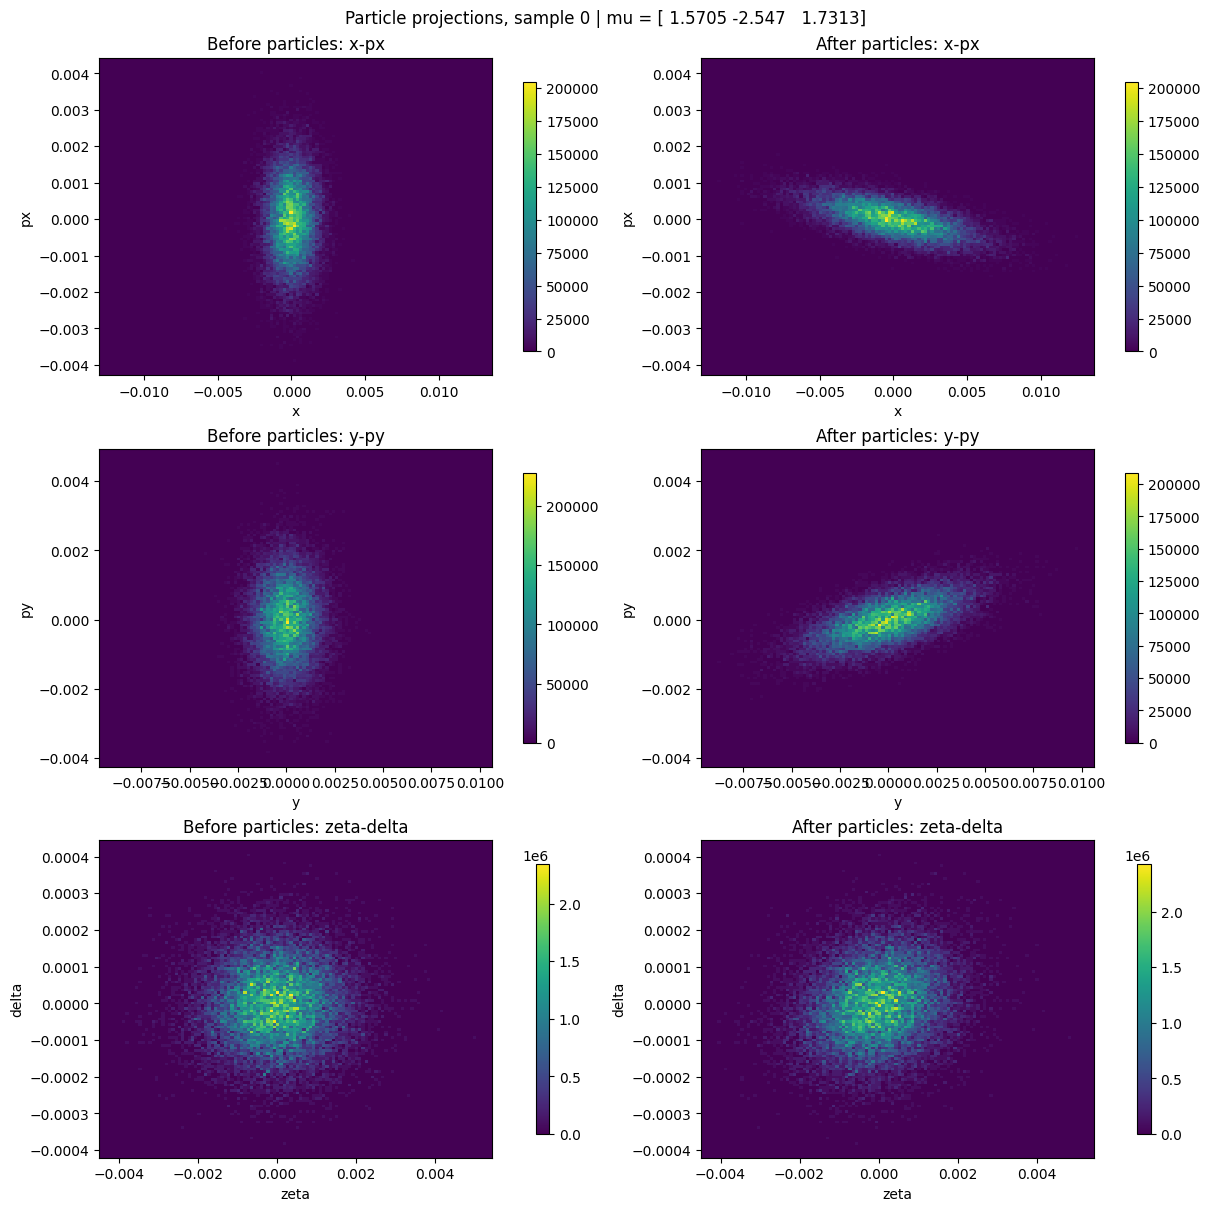

In [12]:
plot_particle_phase_space_projections("xsuite_operator_coeff_dataset.npz", idx=0)

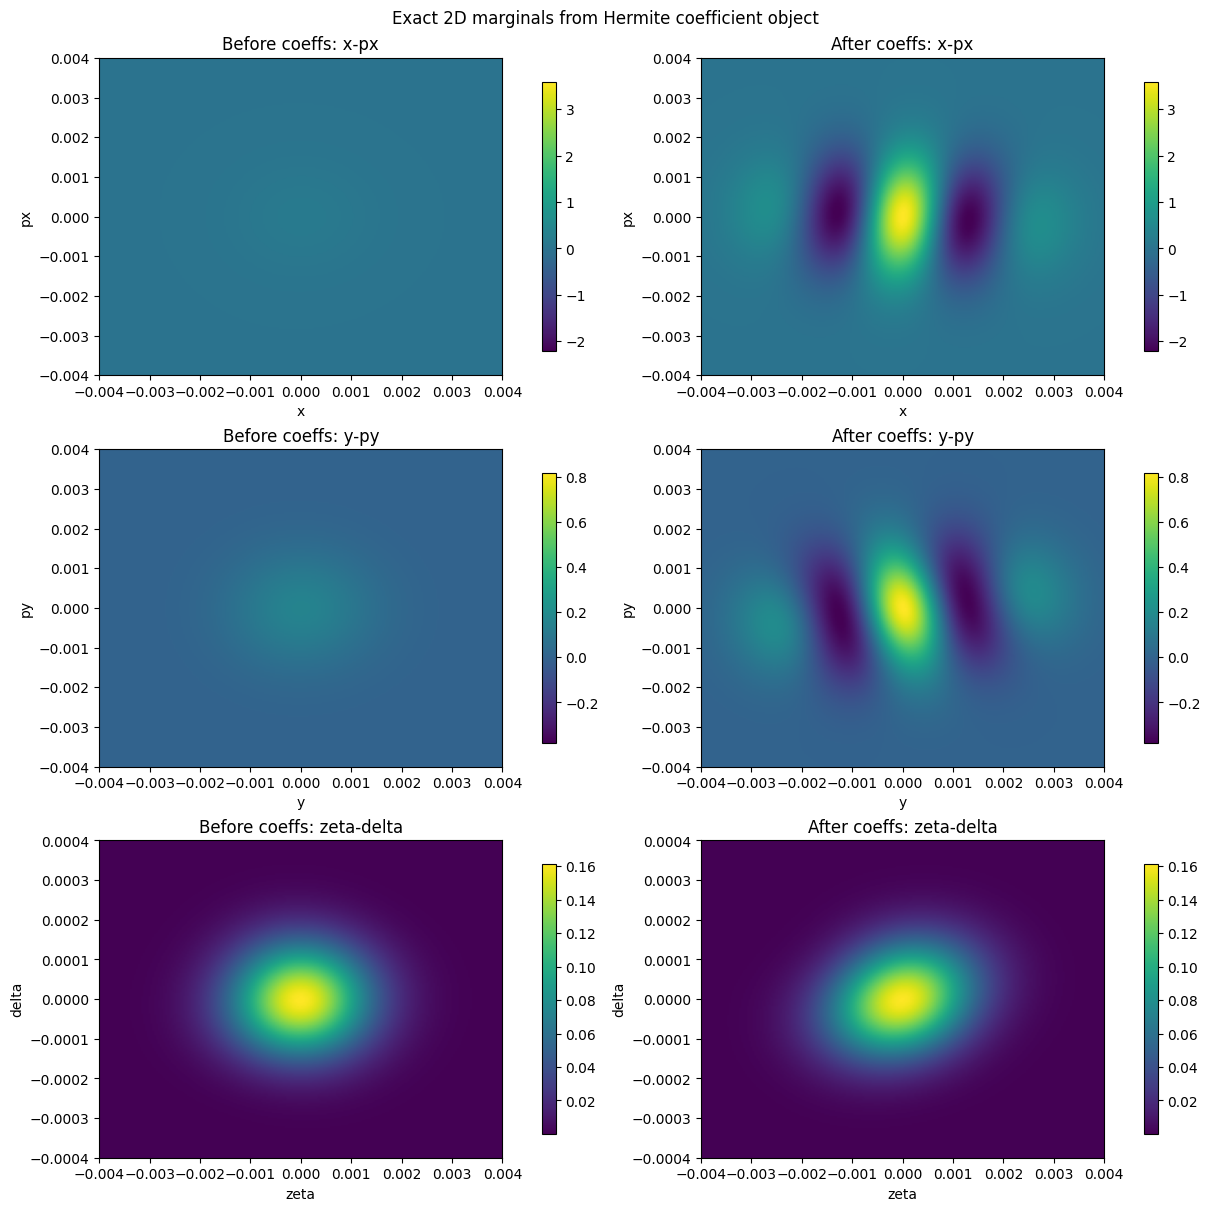

In [13]:
data = np.load("xsuite_operator_coeff_dataset.npz")
basis = basis_from_saved_dataset("xsuite_operator_coeff_dataset.npz")

plot_coeff_phase_space_projections(
    coeffs_before=data["X_coeffs"][0],
    coeffs_after=data["Y_coeffs"][0],
    basis=basis,
    grid_points=220,
    u_range=(-4, 4),
)

Training on device: cuda
Epoch    1 | train_loss=1.803998e+00 | val_loss=2.144235e+00
Epoch    2 | train_loss=1.721997e+00 | val_loss=2.073583e+00
Epoch    3 | train_loss=1.556814e+00 | val_loss=1.992623e+00
Epoch    4 | train_loss=1.407137e+00 | val_loss=1.939098e+00
Epoch    5 | train_loss=1.248557e+00 | val_loss=1.881447e+00
Epoch    6 | train_loss=1.162206e+00 | val_loss=1.870808e+00
Epoch    7 | train_loss=1.065034e+00 | val_loss=1.807189e+00
Epoch    8 | train_loss=9.680841e-01 | val_loss=1.797079e+00
Epoch    9 | train_loss=9.251429e-01 | val_loss=1.802039e+00
Epoch   10 | train_loss=8.682113e-01 | val_loss=1.791976e+00
Epoch   11 | train_loss=8.115769e-01 | val_loss=1.732261e+00
Epoch   12 | train_loss=8.112632e-01 | val_loss=1.762560e+00
Epoch   13 | train_loss=7.579836e-01 | val_loss=1.697045e+00
Epoch   14 | train_loss=7.190209e-01 | val_loss=1.712150e+00
Epoch   15 | train_loss=6.823401e-01 | val_loss=1.666506e+00
Epoch   16 | train_loss=6.277608e-01 | val_loss=1.656630e+00

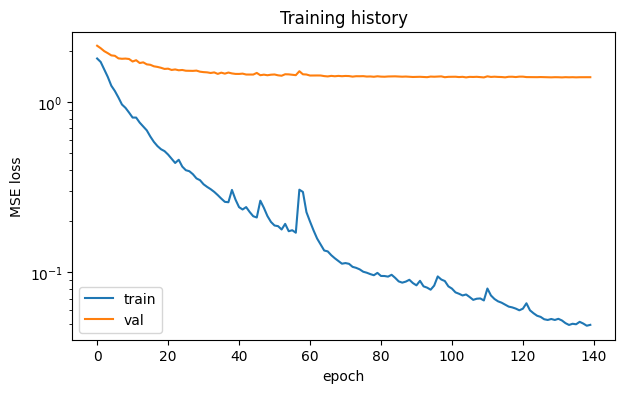

In [14]:
device = "cuda" if torch is not None and torch.cuda.is_available() else "cpu"   
print(f"Training on device: {device}")
artifacts = train_coeff_operator_model(
    dataset_npz="xsuite_operator_coeff_dataset.npz",
    hidden=256,
    depth=4,
    dropout=0.05,
    batch_size=64,
    max_epochs=300,
    lr=1e-3,
    weight_decay=1e-6,
    val_fraction=0.1,
    patience=30,
    seed=123,
    device=device,   # or "cuda"
)
plot_training_history(artifacts["history"])

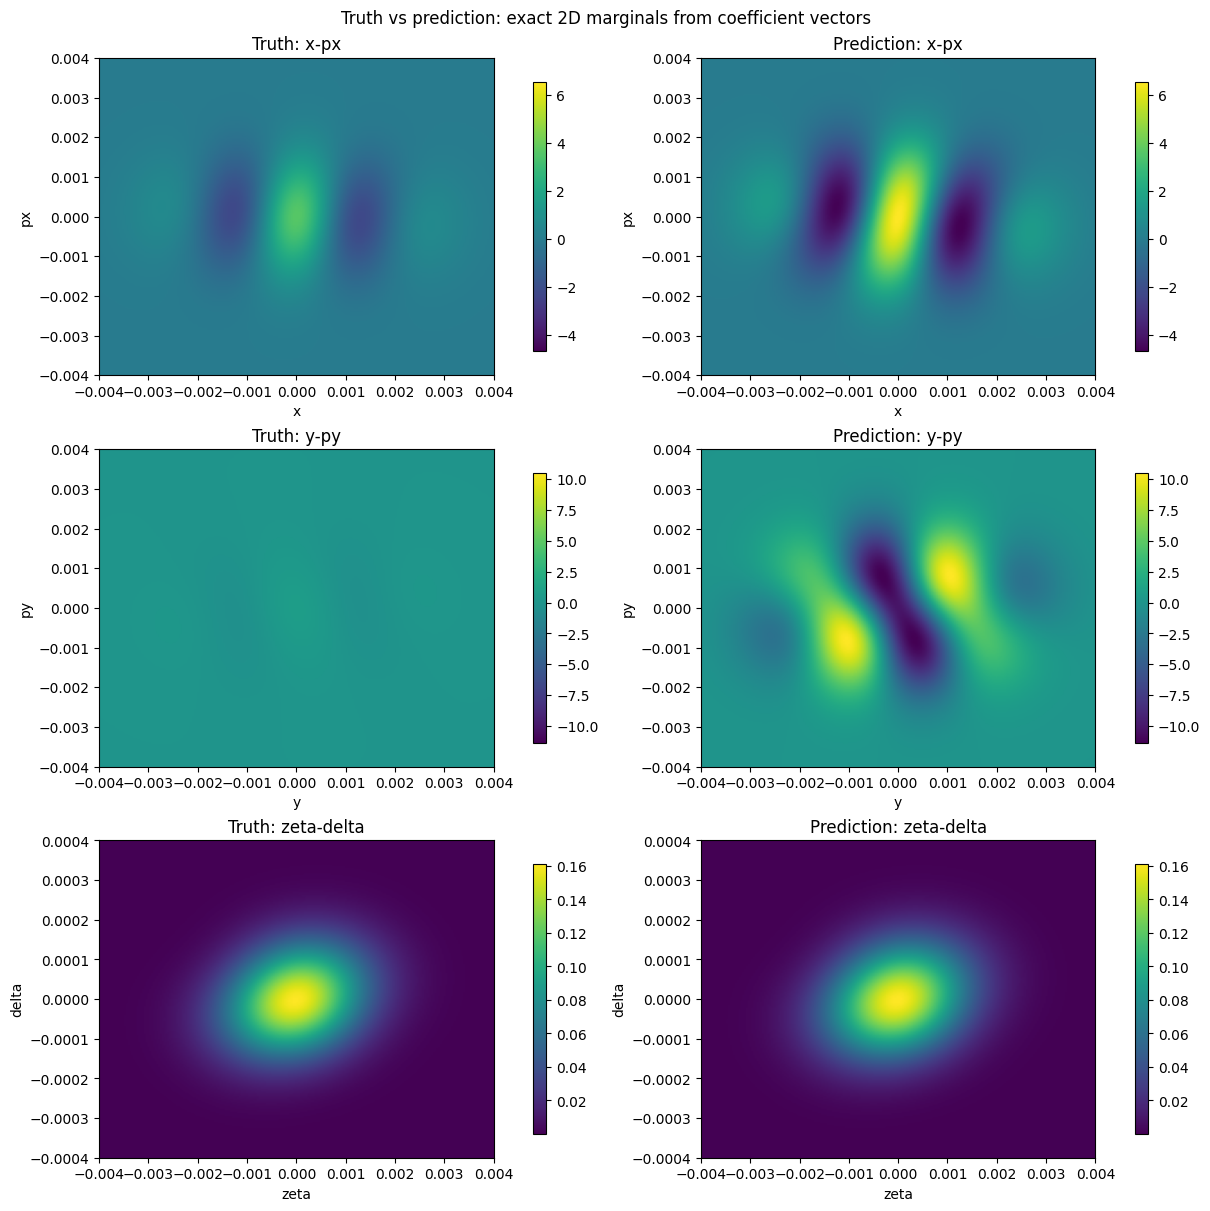

In [15]:
data = np.load("xsuite_operator_coeff_dataset.npz")
basis = basis_from_saved_dataset("xsuite_operator_coeff_dataset.npz")

idx = 0
X0 = data["X_coeffs"][idx:idx+1]
MU0 = data["MU"][idx:idx+1]
Y_true = data["Y_coeffs"][idx]

Y_pred = predict_coeffs(artifacts, X0, MU0)[0]

plot_true_vs_pred_projections_from_coeffs(
    coeffs_true=Y_true,
    coeffs_pred=Y_pred,
    basis=basis,
    grid_points=220,
    u_range=(-4, 4),
)

In [ ]:
def _softmax_stable(logw: np.ndarray) -> np.ndarray:
    logw = np.asarray(logw, dtype=float)
    m = np.max(logw)
    w = np.exp(logw - m)
    s = np.sum(w)
    if not np.isfinite(s) or s <= 0:
        raise RuntimeError("Invalid weights in softmax.")
    return w / s


def sample_from_coeff_distribution_positive(
    basis: HermiteDensity6D,
    coeffs: np.ndarray,
    n_samples: int = 5000,
    proposal_size: int = 100000,
    seed: int = 123,
    return_weights: bool = False,
):
    """
    Sample from the positive surrogate distribution

        rho(u) ∝ gamma(u) * exp(Phi(u) @ coeffs)

    by self-normalized importance resampling from the Gaussian base gamma.

    Since proposal is gamma, weights are:
        w(u) ∝ exp(Phi(u) @ coeffs)

    Returns
    -------
    z_samples : [n_samples, 6]
        Samples in physical coordinates.
    extra : dict, optional
        Includes effective sample size and raw proposal samples if return_weights=True.
    """
    rng = np.random.default_rng(seed)
    coeffs = np.asarray(coeffs, dtype=float)

    if coeffs.shape != (basis.n_coeffs,):
        raise ValueError(f"Expected coeffs shape ({basis.n_coeffs},), got {coeffs.shape}")

    # proposal in normalized coordinates
    u_prop = rng.normal(size=(proposal_size, 6))
    Phi = basis.eval_basis(u_prop)
    logw = Phi @ coeffs
    probs = _softmax_stable(logw)

    ess = 1.0 / np.sum(probs**2)

    idx = rng.choice(proposal_size, size=n_samples, replace=True, p=probs)
    u_samp = u_prop[idx]

    # map back to physical coordinates when transform is diagonal or general invertible
    # u = (z-center) @ T.T   =>   z = center + u @ (T^{-1}).T
    T = basis.normalizer.transform
    Tinv = np.linalg.inv(T)
    z_samp = basis.normalizer.center[None, :] + u_samp @ Tinv.T

    if return_weights:
        return z_samp.astype(np.float32), {
            "proposal_u": u_prop.astype(np.float32),
            "proposal_probs": probs.astype(np.float64),
            "ess": float(ess),
        }

    return z_samp.astype(np.float32)


def compare_mean_and_cov(z_true: np.ndarray, z_pred: np.ndarray) -> dict:
    """
    Compare first and second moments of two 6D clouds.
    """
    z_true = np.asarray(z_true, dtype=float)
    z_pred = np.asarray(z_pred, dtype=float)

    mu_true = z_true.mean(axis=0)
    mu_pred = z_pred.mean(axis=0)

    cov_true = np.cov(z_true.T)
    cov_pred = np.cov(z_pred.T)

    return {
        "mean_true": mu_true,
        "mean_pred": mu_pred,
        "mean_l2": float(np.linalg.norm(mu_true - mu_pred)),
        "cov_true": cov_true,
        "cov_pred": cov_pred,
        "cov_fro": float(np.linalg.norm(cov_true - cov_pred, ord="fro")),
    }


def gaussian_kernel_matrix(X: np.ndarray, Y: np.ndarray, sigma: Optional[float] = None) -> np.ndarray:
    """
    Gaussian kernel matrix K_ij = exp(-||x_i-y_j||^2 / (2 sigma^2))
    """
    X = np.asarray(X, dtype=float)
    Y = np.asarray(Y, dtype=float)

    XX = np.sum(X**2, axis=1, keepdims=True)
    YY = np.sum(Y**2, axis=1, keepdims=True).T
    D2 = np.maximum(XX + YY - 2.0 * X @ Y.T, 0.0)

    if sigma is None:
        # median heuristic on a subset
        sub = D2.ravel()
        sub = sub[np.isfinite(sub)]
        med = np.median(sub[sub > 0]) if np.any(sub > 0) else 1.0
        sigma = math.sqrt(max(med / 2.0, 1e-12))

    return np.exp(-D2 / (2.0 * sigma**2))


def mmd_rbf(X: np.ndarray, Y: np.ndarray, sigma: Optional[float] = None) -> float:
    """
    Biased MMD^2 with Gaussian kernel.
    Smaller is better.
    """
    Kxx = gaussian_kernel_matrix(X, X, sigma=sigma)
    Kyy = gaussian_kernel_matrix(Y, Y, sigma=sigma)
    Kxy = gaussian_kernel_matrix(X, Y, sigma=sigma)

    return float(Kxx.mean() + Kyy.mean() - 2.0 * Kxy.mean())


def sliced_wasserstein_approx(
    X: np.ndarray,
    Y: np.ndarray,
    n_proj: int = 64,
    seed: int = 123,
) -> float:
    """
    Approximate sliced Wasserstein distance between 6D clouds.
    Smaller is better.

    Computes average 1D Wasserstein distance over random projections.
    Requires same number of samples in X and Y for direct quantile matching.
    """
    rng = np.random.default_rng(seed)
    X = np.asarray(X, dtype=float)
    Y = np.asarray(Y, dtype=float)

    n = min(len(X), len(Y))
    X = X[:n]
    Y = Y[:n]

    d = X.shape[1]
    vals = []

    for _ in range(n_proj):
        v = rng.normal(size=d)
        v /= np.linalg.norm(v) + 1e-15

        x1 = np.sort(X @ v)
        y1 = np.sort(Y @ v)

        vals.append(np.mean(np.abs(x1 - y1)))

    return float(np.mean(vals))


def coefficient_errors(c_true: np.ndarray, c_pred: np.ndarray) -> dict:
    c_true = np.asarray(c_true, dtype=float)
    c_pred = np.asarray(c_pred, dtype=float)

    l2 = np.linalg.norm(c_true - c_pred)
    rel = l2 / (np.linalg.norm(c_true) + 1e-12)

    return {
        "coeff_l2": float(l2),
        "coeff_rel_l2": float(rel),
    }


def plot_distribution_comparison(
    z_true: np.ndarray,
    z_pred: np.ndarray,
    bins: int = 120,
    cmap: str = "viridis",
    figsize=(12, 12),
    title: str = "True vs predicted sampled distributions",
):
    """
    Compare two 6D sampled distributions through the standard phase-space projections.
    """
    z_true = np.asarray(z_true, dtype=float)
    z_pred = np.asarray(z_pred, dtype=float)

    projections = [
        (0, 3, "x", "px"),
        (1, 4, "y", "py"),
        (2, 5, "zeta", "delta"),
    ]

    fig, axes = plt.subplots(3, 2, figsize=figsize, constrained_layout=True)

    for row, (i, j, xl, yl) in enumerate(projections):
        all2 = np.vstack([z_true[:, [i, j]], z_pred[:, [i, j]]])
        xpad = 0.05 * (all2[:, 0].max() - all2[:, 0].min() + 1e-15)
        ypad = 0.05 * (all2[:, 1].max() - all2[:, 1].min() + 1e-15)
        ranges = [
            [all2[:, 0].min() - xpad, all2[:, 0].max() + xpad],
            [all2[:, 1].min() - ypad, all2[:, 1].max() + ypad],
        ]

        im0 = axes[row, 0].hist2d(
            z_true[:, i], z_true[:, j],
            bins=bins, range=ranges, density=True, cmap=cmap
        )[3]
        fig.colorbar(im0, ax=axes[row, 0], shrink=0.85)
        axes[row, 0].set_title(f"Truth: {xl}-{yl}")
        axes[row, 0].set_xlabel(xl)
        axes[row, 0].set_ylabel(yl)

        im1 = axes[row, 1].hist2d(
            z_pred[:, i], z_pred[:, j],
            bins=bins, range=ranges, density=True, cmap=cmap
        )[3]
        fig.colorbar(im1, ax=axes[row, 1], shrink=0.85)
        axes[row, 1].set_title(f"Prediction: {xl}-{yl}")
        axes[row, 1].set_xlabel(xl)
        axes[row, 1].set_ylabel(yl)

    fig.suptitle(title)
    plt.show()


def full_distribution_test(
    basis: HermiteDensity6D,
    coeffs_true: np.ndarray,
    coeffs_pred: np.ndarray,
    z_true_particles: Optional[np.ndarray] = None,
    n_pred_samples: int = 5000,
    proposal_size: int = 100000,
    seed: int = 123,
    make_plot: bool = True,
) -> dict:
    """
    Full distribution-level test.

    - Samples a predicted 6D distribution from coeffs_pred
    - Uses either true particles or truth sampled from coeffs_true
    - Computes:
        * coefficient errors
        * mean / covariance errors
        * MMD in 6D
        * approximate sliced Wasserstein in 6D
    - Optionally plots standard 2D phase-space projections

    Returns a dictionary with all diagnostics.
    """
    coeff_diag = coefficient_errors(coeffs_true, coeffs_pred)

    z_pred = sample_from_coeff_distribution_positive(
        basis=basis,
        coeffs=coeffs_pred,
        n_samples=n_pred_samples,
        proposal_size=proposal_size,
        seed=seed,
    )

    if z_true_particles is not None:
        z_true = np.asarray(z_true_particles, dtype=float)
        if len(z_true) > n_pred_samples:
            rng = np.random.default_rng(seed + 1)
            idx = rng.choice(len(z_true), size=n_pred_samples, replace=False)
            z_true = z_true[idx]
    else:
        z_true = sample_from_coeff_distribution_positive(
            basis=basis,
            coeffs=coeffs_true,
            n_samples=n_pred_samples,
            proposal_size=proposal_size,
            seed=seed + 1,
        )

    moment_diag = compare_mean_and_cov(z_true, z_pred)
    mmd_val = mmd_rbf(z_true, z_pred)
    sw_val = sliced_wasserstein_approx(z_true, z_pred, n_proj=64, seed=seed + 2)

    out = {
        **coeff_diag,
        **moment_diag,
        "mmd_rbf": float(mmd_val),
        "sliced_wasserstein": float(sw_val),
        "z_true_sampled": z_true,
        "z_pred_sampled": z_pred,
    }

    if make_plot:
        plot_distribution_comparison(
            z_true=z_true,
            z_pred=z_pred,
            title=(
                "Distribution test | "
                f"coeff_rel={out['coeff_rel_l2']:.3e}, "
                f"MMD={out['mmd_rbf']:.3e}, "
                f"SW={out['sliced_wasserstein']:.3e}"
            ),
        )

    return out

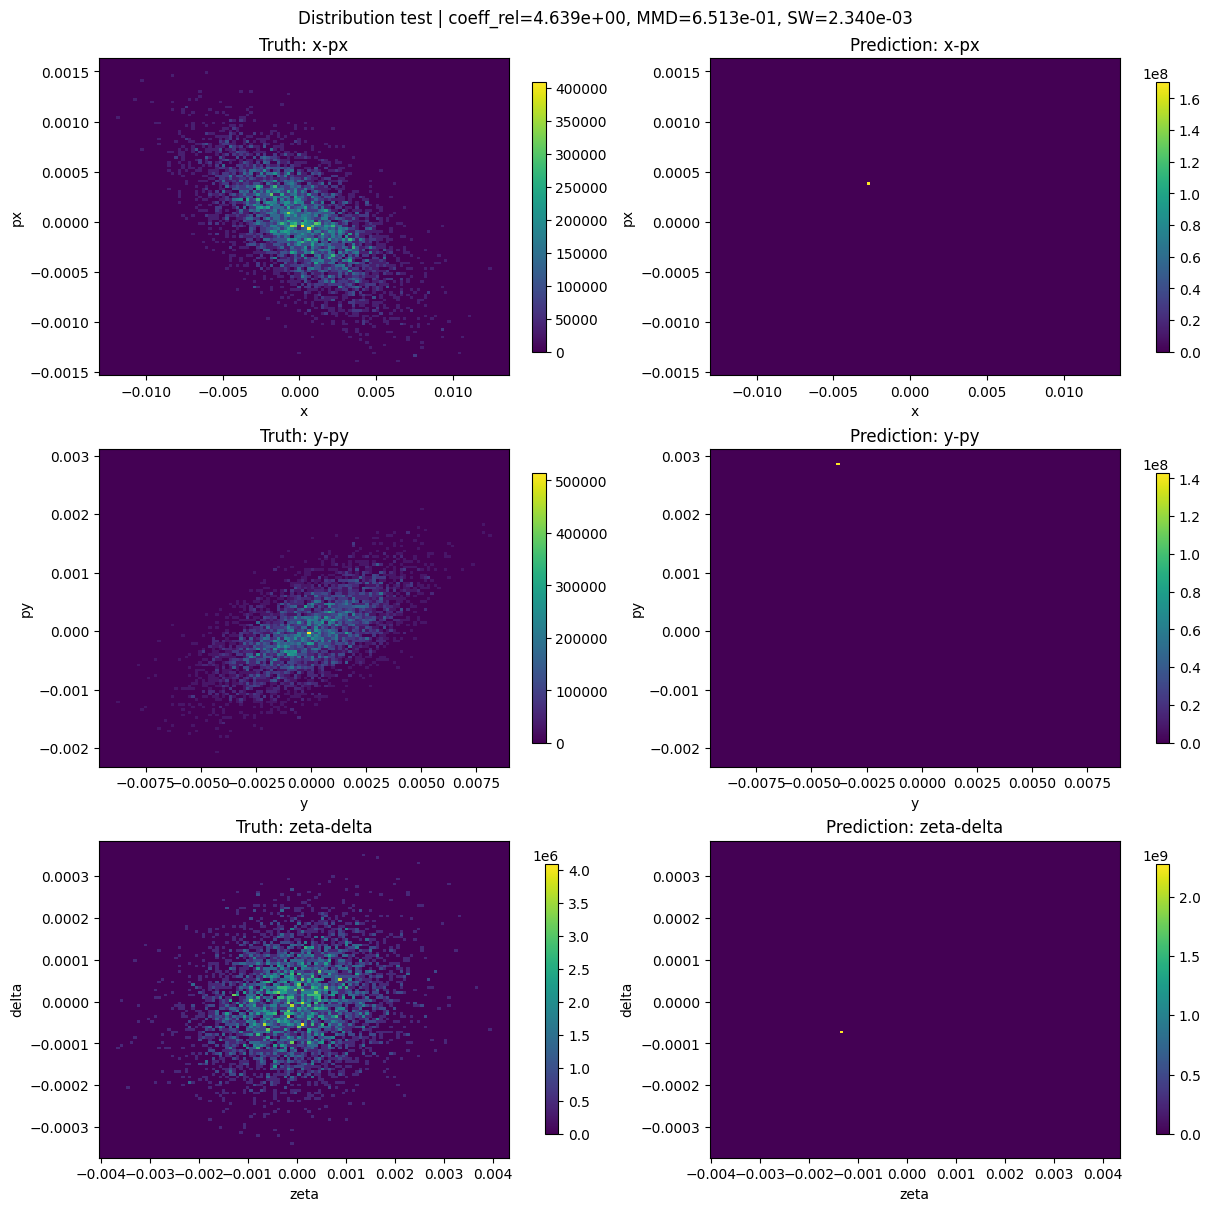

coeff_l2: 2.284442e+02
coeff_rel_l2: 4.639311e+00
mean_l2: 5.650573e-03
cov_fro: 1.087207e-05
mmd_rbf: 6.512639e-01
sliced_wasserstein: 2.340182e-03


In [17]:
data = np.load("xsuite_operator_coeff_dataset.npz")
basis = basis_from_saved_dataset("xsuite_operator_coeff_dataset.npz")

idx = 0
X0 = data["X_coeffs"][idx:idx+1]
MU0 = data["MU"][idx:idx+1]

Y_true = data["Y_coeffs"][idx]
Y_pred = predict_coeffs(artifacts, X0, MU0)[0]

# if you saved raw particles, use them as the ground-truth distribution
z_true_particles = data["Y_particles"][idx] if "Y_particles" in data.files else None

diag = full_distribution_test(
    basis=basis,
    coeffs_true=Y_true,
    coeffs_pred=Y_pred,
    z_true_particles=z_true_particles,
    n_pred_samples=5000,
    proposal_size=120000,
    seed=123,
    make_plot=True,
)

for k, v in diag.items():
    if isinstance(v, float):
        print(f"{k}: {v:.6e}")

In [18]:
def evaluate_distribution_test_set(
    dataset_npz: str,
    artifacts: dict,
    n_eval: int = 50,
    n_pred_samples: int = 4000,
    proposal_size: int = 80000,
    seed: int = 123,
):
    data = np.load(dataset_npz)
    basis = basis_from_saved_dataset(dataset_npz)

    X = data["X_coeffs"]
    Y = data["Y_coeffs"]
    MU = data["MU"]
    has_particles = "Y_particles" in data.files

    rng = np.random.default_rng(seed)
    idxs = rng.choice(len(X), size=min(n_eval, len(X)), replace=False)

    rows = []
    for idx in idxs:
        Y_pred = predict_coeffs(artifacts, X[idx:idx+1], MU[idx:idx+1])[0]
        z_true_particles = data["Y_particles"][idx] if has_particles else None

        diag = full_distribution_test(
            basis=basis,
            coeffs_true=Y[idx],
            coeffs_pred=Y_pred,
            z_true_particles=z_true_particles,
            n_pred_samples=n_pred_samples,
            proposal_size=proposal_size,
            seed=int(seed + idx),
            make_plot=False,
        )

        rows.append({
            "idx": int(idx),
            "coeff_rel_l2": diag["coeff_rel_l2"],
            "mean_l2": diag["mean_l2"],
            "cov_fro": diag["cov_fro"],
            "mmd_rbf": diag["mmd_rbf"],
            "sliced_wasserstein": diag["sliced_wasserstein"],
        })

    return rows

In [19]:
rows = evaluate_distribution_test_set(
    "xsuite_operator_coeff_dataset.npz",
    artifacts,
    n_eval=30,
    n_pred_samples=4000,
    proposal_size=80000,
)

for key in ["coeff_rel_l2", "mean_l2", "cov_fro", "mmd_rbf", "sliced_wasserstein"]:
    vals = np.array([r[key] for r in rows], dtype=float)
    print(key, "mean =", vals.mean(), "std =", vals.std(), "median =", np.median(vals))

coeff_rel_l2 mean = 1.3199670399269687 std = 1.136631261328434 median = 1.1735428494459916
mean_l2 mean = 0.004989179604857258 std = 0.000432042852164373 median = 0.004960484655516348
cov_fro mean = 3.680022957163206e-05 std = 2.2717648503533706e-05 median = 2.4561823814537794e-05
mmd_rbf mean = 0.615354182462957 std = 0.01750817642632352 median = 0.6106681946168847
sliced_wasserstein mean = 0.0024712006690058904 std = 0.0004040653862559854 median = 0.0023595670690940334
